In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
print("설치 완료!")
print(f"pandas 버전: {pd.__version__}")
print(f"numpy 버전: {np.__version__}")

설치 완료!
pandas 버전: 3.0.3
numpy 버전: 2.5.0


In [2]:
import pandas as pd

df = pd.read_csv('commodity_trade_statistics_data.csv')
print(df.shape)
print(df.columns.tolist())

C:\Users\jshj8\AppData\Local\Temp\ipykernel_34540\207499668.py:3: DtypeWarning: Columns (0: comm_code) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('commodity_trade_statistics_data.csv')


(8225871, 10)
['country_or_area', 'year', 'comm_code', 'commodity', 'flow', 'trade_usd', 'weight_kg', 'quantity_name', 'quantity', 'category']


In [3]:
print("=== 첫 5행 ===")
print(df.head())

print("\n=== 연도 범위 ===")
print(f"최소: {df['year'].min()}년 / 최대: {df['year'].max()}년")

print("\n=== 수출입 구분 ===")
print(df['flow'].value_counts())

print("\n=== 카테고리 종류 ===")
print(df['category'].value_counts().head(10))

=== 첫 5행 ===
  country_or_area  year comm_code  \
0     Afghanistan  2016     10410   
1     Afghanistan  2016     10420   
2     Afghanistan  2008     10210   
3         Albania  2016     10290   
4         Albania  2016     10392   

                                         commodity    flow  trade_usd  \
0                                      Sheep, live  Export       6088   
1                                      Goats, live  Export       3958   
2          Bovine animals, live pure-bred breeding  Import    1026804   
3  Bovine animals, live, except pure-bred breeding  Import    2414533   
4    Swine, live except pure-bred breeding > 50 kg  Import   14265937   

   weight_kg    quantity_name  quantity         category  
0     2339.0  Number of items      51.0  01_live_animals  
1      984.0  Number of items      53.0  01_live_animals  
2      272.0  Number of items    3769.0  01_live_animals  
3  1114023.0  Number of items    6853.0  01_live_animals  
4  9484953.0  Number of items 

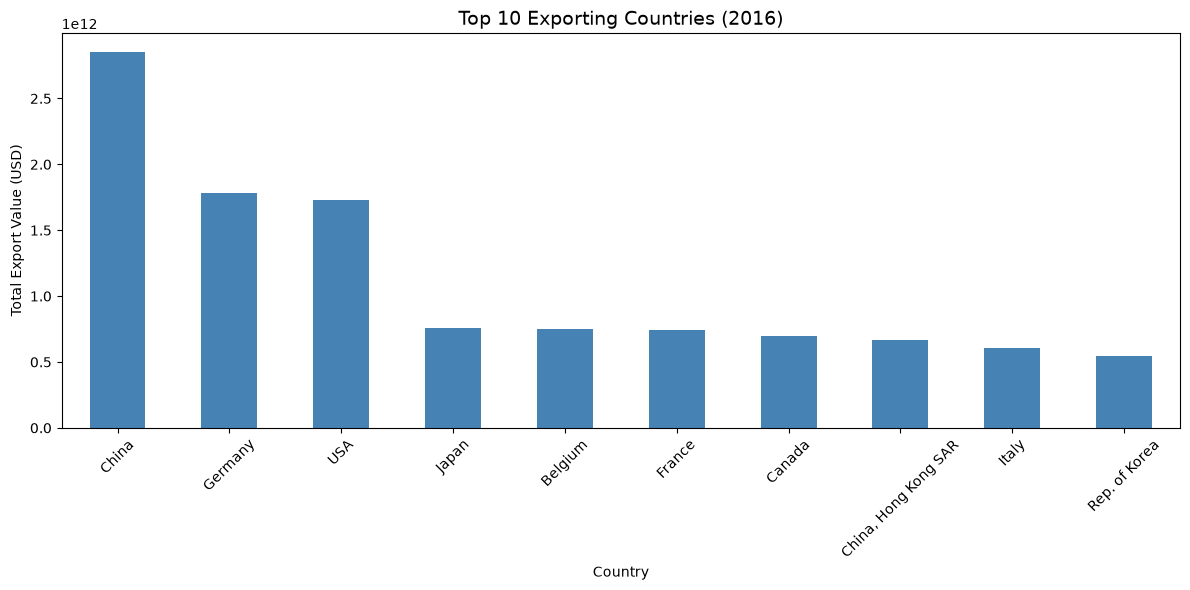

country_or_area
China                   2853462302506
Germany                 1782429005485
USA                     1728911747423
Japan                    756067495398
Belgium                  753243878558
France                   744282018282
Canada                   700107793070
China, Hong Kong SAR     666504854119
Italy                    609551585099
Rep. of Korea            546485753022
Name: trade_usd, dtype: int64


In [4]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

# 2016년 수출 상위 10개국
export_2016 = df[(df['year'] == 2016) & (df['flow'] == 'Export')]
top_exporters = export_2016.groupby('country_or_area')['trade_usd'].sum().sort_values(ascending=False).head(10)

# 그래프
fig, ax = plt.subplots(figsize=(12, 6))
top_exporters.plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Top 10 Exporting Countries (2016)', fontsize=14)
ax.set_xlabel('Country')
ax.set_ylabel('Total Export Value (USD)')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

print(top_exporters)

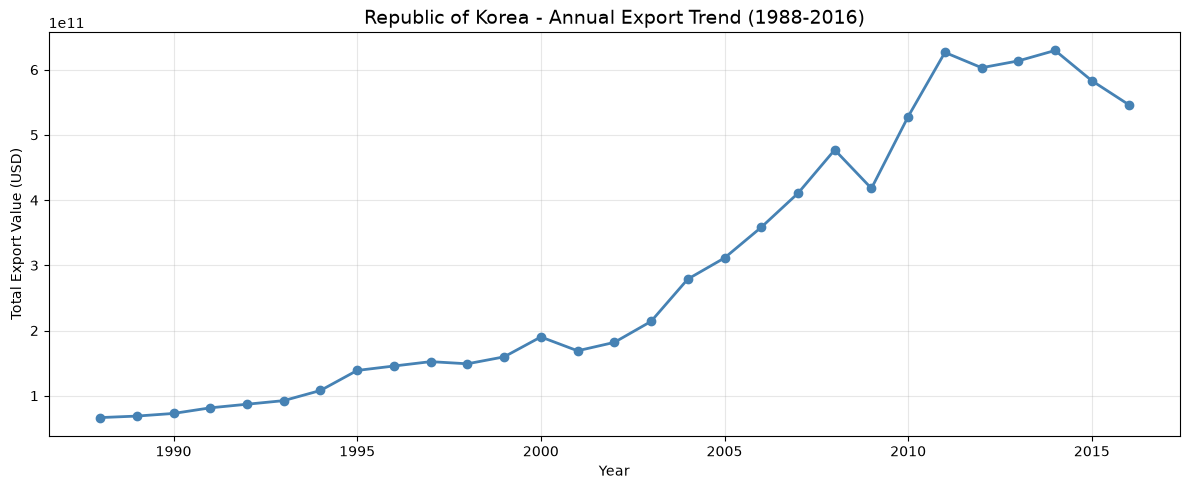


=== 한국 2016년 주요 수출 카테고리 ===
category
all_commodities                                      495417715559
89_ships_boats_and_other_floating_structures          33143837020
60_knitted_or_crocheted_fabric                         3385466470
88_aircraft_spacecraft_and_parts_thereof               1896456482
79_zinc_and_articles_thereof                           1300839130
59_impregnated_coated_or_laminated_textile_fabric      1289342837
21_miscellaneous_edible_preparations                   1116901126
24_tobacco_and_manufactured_tobacco_substitutes        1014471879
Name: trade_usd, dtype: int64


In [5]:
# 한국 수출 트렌드 분석 (연도별)
korea_export = df[(df['country_or_area'] == 'Rep. of Korea') & (df['flow'] == 'Export')]
korea_yearly = korea_export.groupby('year')['trade_usd'].sum()

fig, ax = plt.subplots(figsize=(12, 5))
korea_yearly.plot(kind='line', ax=ax, color='steelblue', marker='o', linewidth=2)
ax.set_title('Republic of Korea - Annual Export Trend (1988-2016)', fontsize=14)
ax.set_xlabel('Year')
ax.set_ylabel('Total Export Value (USD)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 한국 주요 수출 카테고리 (2016)
korea_2016 = korea_export[korea_export['year'] == 2016]
korea_category = korea_2016.groupby('category')['trade_usd'].sum().sort_values(ascending=False).head(8)
print("\n=== 한국 2016년 주요 수출 카테고리 ===")
print(korea_category)

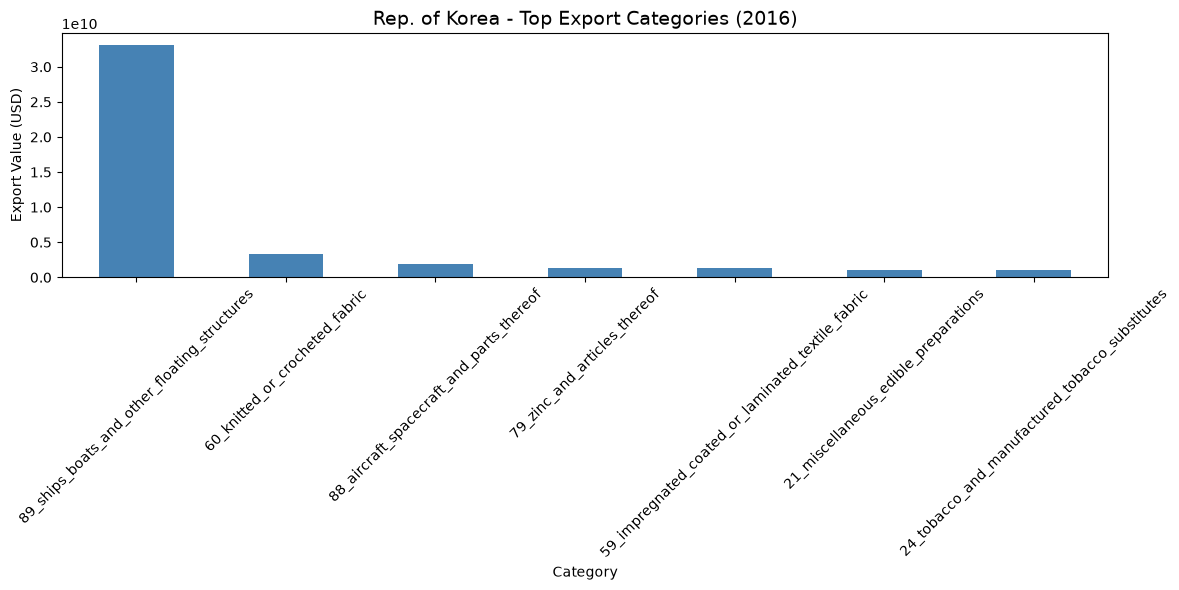

=== 전체 카테고리 목록 ===
['01_live_animals', '02_meat_and_edible_meat_offal', '03_fish_crustaceans_molluscs_aquatic_invertebrates_ne', '04_dairy_products_eggs_honey_edible_animal_product_nes', '05_products_of_animal_origin_nes', '06_live_trees_plants_bulbs_roots_cut_flowers_etc', '07_edible_vegetables_and_certain_roots_and_tubers', '08_edible_fruit_nuts_peel_of_citrus_fruit_melons', '09_coffee_tea_mate_and_spices', '10_cereals', '11_milling_products_malt_starches_inulin_wheat_glute', '12_oil_seed_oleagic_fruits_grain_seed_fruit_etc_ne', '13_lac_gums_resins_vegetable_saps_and_extracts_nes', '14_vegetable_plaiting_materials_vegetable_products_nes', '15_animal_vegetable_fats_and_oils_cleavage_products_et', '16_meat_fish_and_seafood_food_preparations_nes', '17_sugars_and_sugar_confectionery', '18_cocoa_and_cocoa_preparations', '19_cereal_flour_starch_milk_preparations_and_products', '20_vegetable_fruit_nut_etc_food_preparations', '21_miscellaneous_edible_preparations', '22_beverages_spirits_and_

In [6]:
# all_commodities 제외하고 다시 분석
korea_category_clean = korea_category[korea_category.index != 'all_commodities']

fig, ax = plt.subplots(figsize=(12, 6))
korea_category_clean.plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Rep. of Korea - Top Export Categories (2016)', fontsize=14)
ax.set_xlabel('Category')
ax.set_ylabel('Export Value (USD)')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

# 데이터셋 카테고리 전체 목록 확인
print("=== 전체 카테고리 목록 ===")
print(sorted(df['category'].unique()))

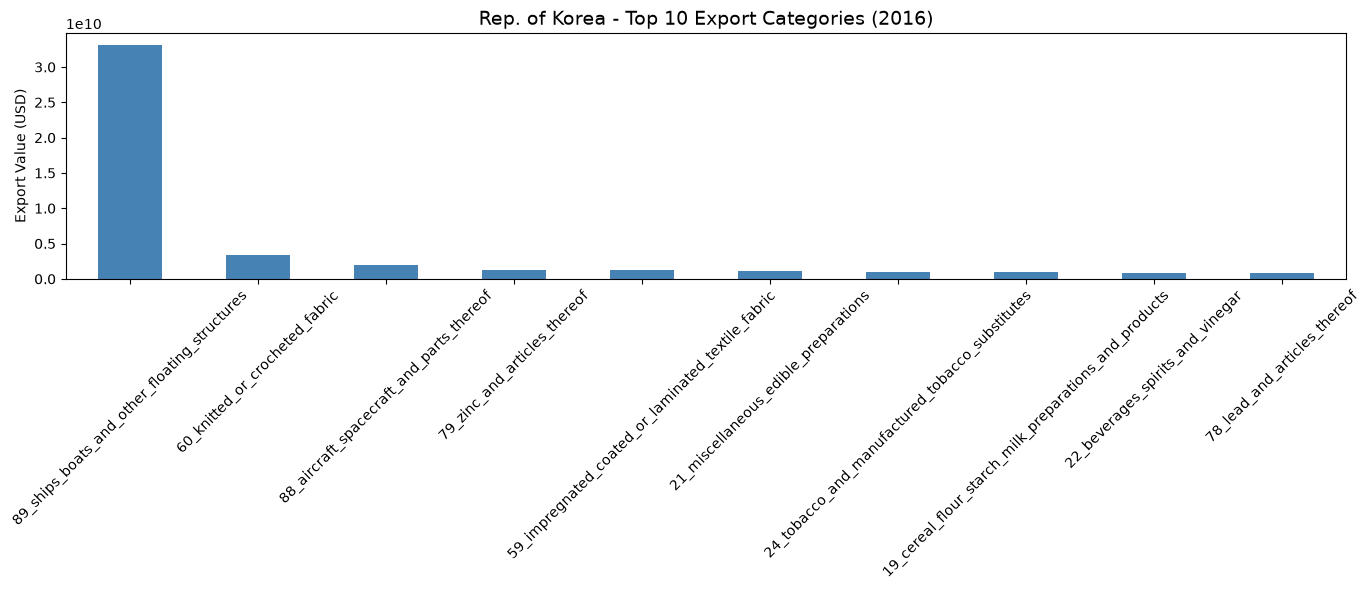

category
89_ships_boats_and_other_floating_structures             33143837020
60_knitted_or_crocheted_fabric                            3385466470
88_aircraft_spacecraft_and_parts_thereof                  1896456482
79_zinc_and_articles_thereof                              1300839130
59_impregnated_coated_or_laminated_textile_fabric         1289342837
21_miscellaneous_edible_preparations                      1116901126
24_tobacco_and_manufactured_tobacco_substitutes           1014471879
19_cereal_flour_starch_milk_preparations_and_products      931067385
22_beverages_spirits_and_vinegar                           788363337
78_lead_and_articles_thereof                               777511306
Name: trade_usd, dtype: int64


In [7]:
# all_commodities, 99번 제외하고 한국 2016 전체 카테고리 TOP 10
korea_2016_clean = korea_2016[
    ~korea_2016['category'].isin(['all_commodities', '99_commodities_not_specified_according_to_kind'])
]
korea_top10 = korea_2016_clean.groupby('category')['trade_usd'].sum().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(14, 6))
korea_top10.plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Rep. of Korea - Top 10 Export Categories (2016)', fontsize=14)
ax.set_xlabel('')
ax.set_ylabel('Export Value (USD)')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

print(korea_top10)

In [8]:
# 반도체, 자동차, 철강 카테고리 한국 데이터 직접 확인
check_categories = [
    '85_electrical_electronic_equipment',
    '87_vehicles_other_than_railway_tramway', 
    '72_iron_and_steel',
    '84_nuclear_reactors_boilers_machinery_etc'
]

korea_all = df[(df['country_or_area'] == 'Rep. of Korea') & 
               (df['flow'] == 'Export') & 
               (df['year'] == 2016) &
               (df['category'].isin(check_categories))]

print(korea_all.groupby('category')['trade_usd'].sum().sort_values(ascending=False))

Series([], Name: trade_usd, dtype: int64)


In [9]:
# 두 파일 불러오기
import pandas as pd

df_tariff = pd.read_excel('Trump_Tariff_Data.xlsx')
df_country = pd.read_csv('Trump_tariffs_by_country.csv')

print("=== Trump Tariff Data ===")
print(df_tariff.shape)
print(df_tariff.columns.tolist())
print(df_tariff.head(3))

print("\n=== Tariffs by Country ===")
print(df_country.shape)
print(df_country.columns.tolist())
print(df_country.head(3))

=== Trump Tariff Data ===
(204, 7)
['Country', 'US 2024 Deficit', 'US 2024 Exports', 'US 2024 Imports (Customs Basis)', 'Trump Tariffs Alleged', 'Trump Response', 'Population']
       Country  US 2024 Deficit  US 2024 Exports  \
0  Afghanistan            -11.1             11.4   
1      Albania             13.4            141.7   
2      Algeria          -1447.1           1014.5   

   US 2024 Imports (Customs Basis)  Trump Tariffs Alleged  Trump Response  \
0                             22.6                   0.49            0.25   
1                            128.3                   0.10            0.10   
2                           2461.6                   0.59            0.29   

   Population  
0  41454761.0  
1   2745972.0  
2  46164219.0  

=== Tariffs by Country ===
(185, 3)
['Country', 'Tariffs charged to USA', 'Reciprocal Tariffs']
          Country  Tariffs charged to USA  Reciprocal Tariffs
0           China                    0.67                0.34
1  European Union   

=== 한국 관련 데이터 ===
             Country  US 2024 Deficit  US 2024 Exports  \
95  Korea, North (-)            114.0            219.0   
96     Korea, South*         -66007.4          65541.8   

    US 2024 Imports (Customs Basis)  Trump Tariffs Alleged  Trump Response  \
95                            228.0                    0.1            0.10   
96                         131549.2                    0.5            0.25   

    Population  
95         NaN  
96         NaN  


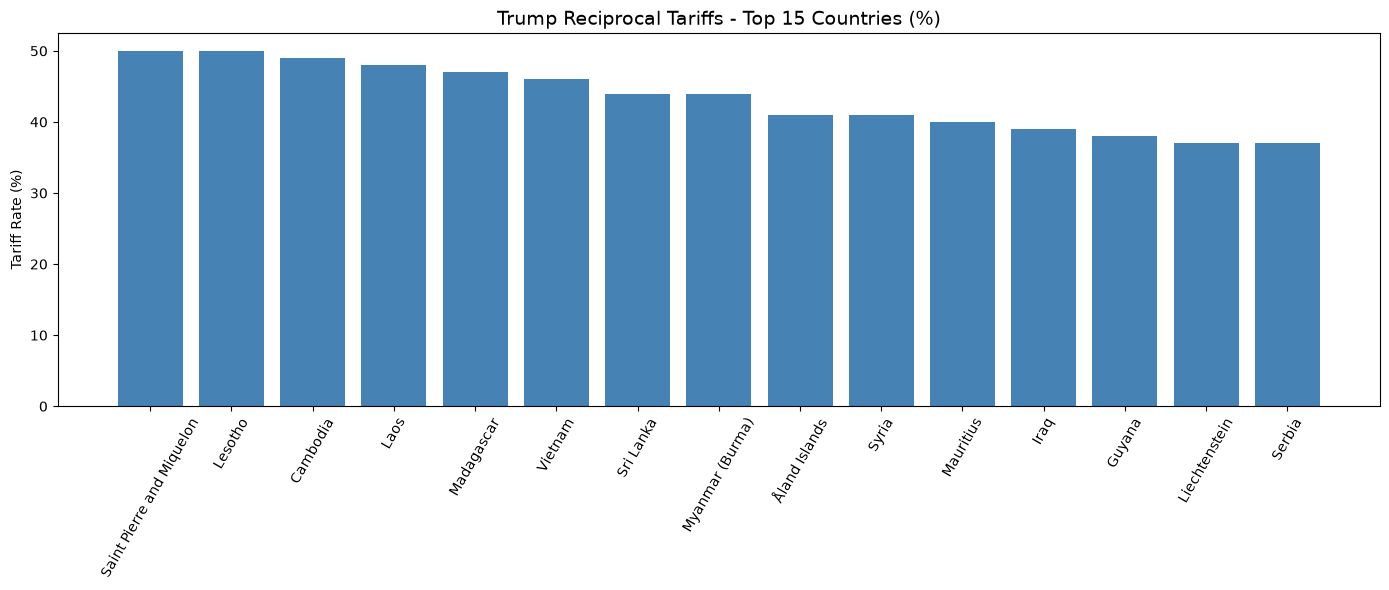

In [11]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

# 한국 데이터 확인
korea = df_tariff[df_tariff['Country'].str.contains('Korea', na=False)]
print("=== 한국 관련 데이터 ===")
print(korea)

# 트럼프 보복관세 상위 15개국
top_tariff = df_country.sort_values('Reciprocal Tariffs', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.bar(top_tariff['Country'], top_tariff['Reciprocal Tariffs'] * 100, color='steelblue')
ax.set_title("Trump Reciprocal Tariffs - Top 15 Countries (%)", fontsize=14)
ax.set_ylabel("Tariff Rate (%)")
ax.tick_params(axis='x', rotation=60)

# 한국 막대 색 강조
for i, country in enumerate(top_tariff['Country']):
    if 'Korea' in str(country):
        bars[i].set_color('crimson')

plt.tight_layout()
plt.show()

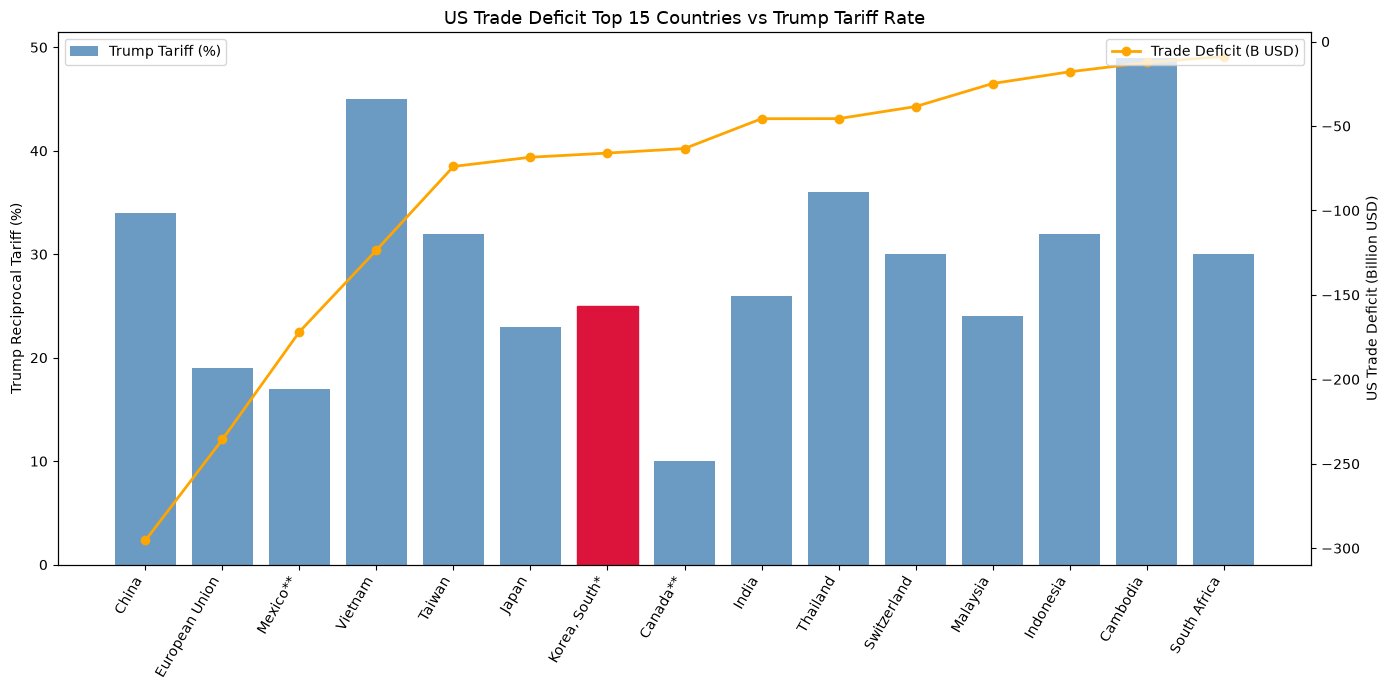

            Country  US 2024 Deficit  Trump Response %
39            China        -295401.6              34.0
61   European Union        -235571.2              19.0
117        Mexico**        -171809.2              17.0
199         Vietnam        -123463.0              45.0
176          Taiwan         -73927.2              32.0
90            Japan         -68467.7              23.0
96    Korea, South*         -66007.4              25.0
34         Canada**         -63335.8              10.0
84            India         -45663.8              26.0
179        Thailand         -45608.9              36.0
174     Switzerland         -38463.3              30.0
109        Malaysia         -24830.1              24.0
85        Indonesia         -17882.6              32.0
32         Cambodia         -12340.2              49.0
163    South Africa          -8836.8              30.0


In [12]:
# 미국 무역적자 상위국 vs 트럼프 보복관세 분석
df_clean = df_tariff.dropna(subset=['US 2024 Deficit', 'Trump Response'])

# 적자 상위 15개국 (미국 기준 적자 = 음수)
top_deficit = df_clean.sort_values('US 2024 Deficit').head(15).copy()
top_deficit['Trump Response %'] = top_deficit['Trump Response'] * 100
top_deficit['Deficit (B USD)'] = top_deficit['US 2024 Deficit'] / 1000

fig, ax1 = plt.subplots(figsize=(14, 7))

x = range(len(top_deficit))
bars = ax1.bar(x, top_deficit['Trump Response %'], color='steelblue', alpha=0.8, label='Trump Tariff (%)')

# 한국 강조
for i, country in enumerate(top_deficit['Country']):
    if 'Korea' in str(country):
        bars[i].set_color('crimson')
        bars[i].set_alpha(1.0)

ax1.set_xticks(x)
ax1.set_xticklabels(top_deficit['Country'], rotation=60, ha='right')
ax1.set_ylabel('Trump Reciprocal Tariff (%)')
ax1.set_title('US Trade Deficit Top 15 Countries vs Trump Tariff Rate', fontsize=13)

ax2 = ax1.twinx()
ax2.plot(x, top_deficit['Deficit (B USD)'], color='orange', marker='o', linewidth=2, label='Trade Deficit (B USD)')
ax2.set_ylabel('US Trade Deficit (Billion USD)')

ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.tight_layout()
plt.show()

print(top_deficit[['Country', 'US 2024 Deficit', 'Trump Response %']].to_string())

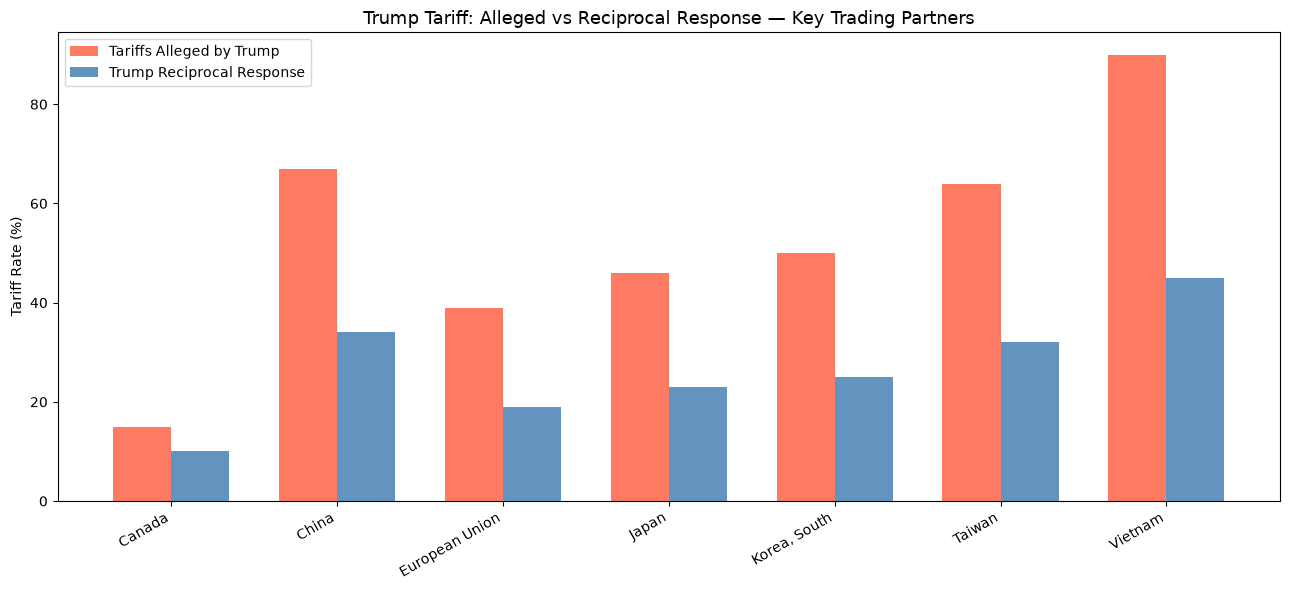

In [13]:
# 한국 집중 분석: KORUS FTA 체결국임에도 25% 관세 부과
# 주요국 관세 부과 전후 비교 시각화

major = df_tariff[df_tariff['Country'].isin([
    'Korea, South*', 'Japan', 'China', 'Vietnam', 'European Union', 'Canada**', 'Taiwan'
])].copy()

major['Alleged %'] = major['Trump Tariffs Alleged'] * 100
major['Response %'] = major['Trump Response'] * 100
major['Country_clean'] = major['Country'].str.replace('*','').str.replace('**','').str.strip()

x = range(len(major))
width = 0.35

fig, ax = plt.subplots(figsize=(13, 6))
b1 = ax.bar([i - width/2 for i in x], major['Alleged %'], width, label="Tariffs Alleged by Trump", color='tomato', alpha=0.85)
b2 = ax.bar([i + width/2 for i in x], major['Response %'], width, label="Trump Reciprocal Response", color='steelblue', alpha=0.85)

ax.set_xticks(list(x))
ax.set_xticklabels(major['Country_clean'], rotation=30, ha='right')
ax.set_ylabel('Tariff Rate (%)')
ax.set_title("Trump Tariff: Alleged vs Reciprocal Response — Key Trading Partners", fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

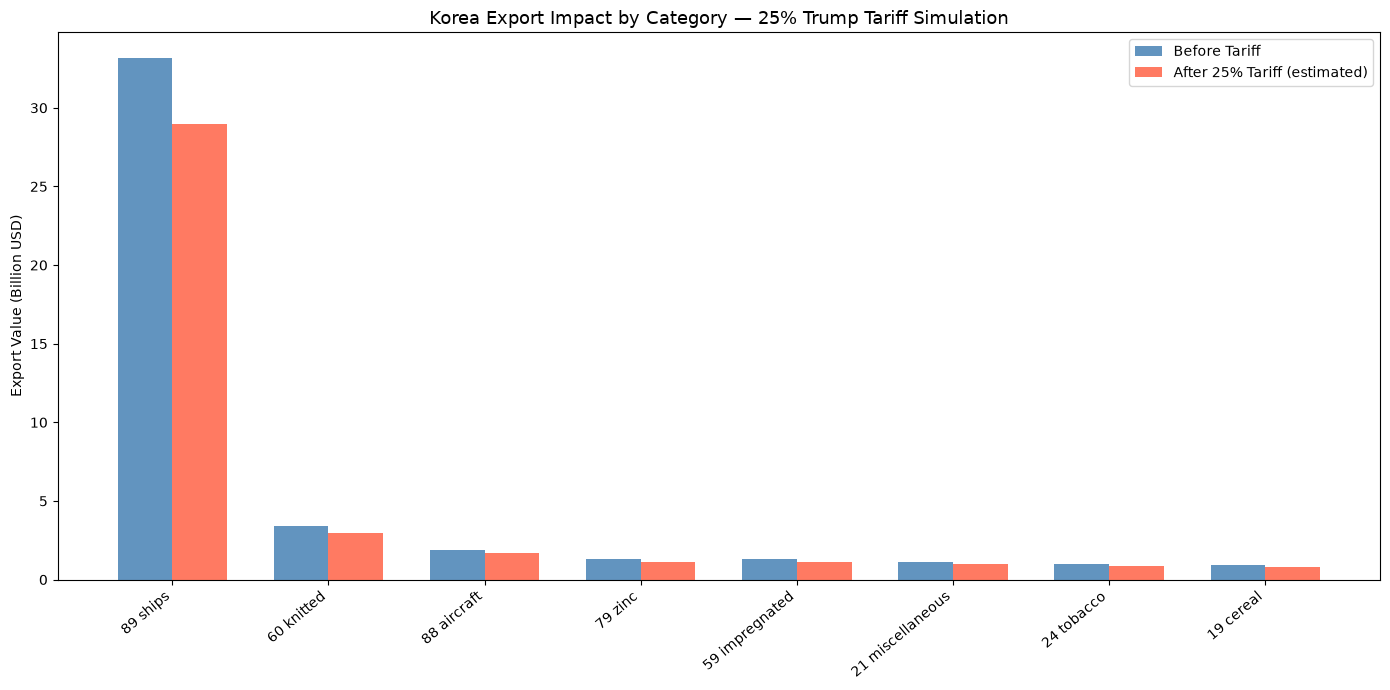


=== 관세 영향 시뮬레이션 결과 ===
카테고리                 수출액(B$)       관세충격(B$)      감소율
-------------------------------------------------------
89 ships              33.14B         4.14B    12.5%
60 knitted             3.39B         0.42B    12.5%
88 aircraft            1.90B         0.24B    12.5%
79 zinc                1.30B         0.16B    12.5%
59 impregnated         1.29B         0.16B    12.5%
21 miscellaneous        1.12B         0.14B    12.5%
24 tobacco             1.01B         0.13B    12.5%
19 cereal              0.93B         0.12B    12.5%


In [15]:
# 한국 주요 수출품목별 25% 관세 영향 시뮬레이션
# 앞서 분석한 UN 무역 데이터에서 한국 2016년 수출 데이터 활용

korea_export_2016 = df[(df['country_or_area'] == 'Rep. of Korea') & 
                        (df['flow'] == 'Export') & 
                        (df['year'] == 2016) &
                        (~df['category'].isin(['all_commodities', '99_commodities_not_specified_according_to_kind']))]

# 카테고리별 수출액 집계
korea_cat = korea_export_2016.groupby('category')['trade_usd'].sum().sort_values(ascending=False).head(8).reset_index()
korea_cat.columns = ['category', 'export_usd']

# 25% 관세 부과 시 수출 감소 추정 (탄력성 -0.5 가정: 관세 1% → 수출 0.5% 감소)
tariff_rate = 0.25
elasticity = -0.5
korea_cat['tariff_impact_usd'] = korea_cat['export_usd'] * tariff_rate * abs(elasticity)
korea_cat['export_after_usd'] = korea_cat['export_usd'] - korea_cat['tariff_impact_usd']
korea_cat['category_clean'] = korea_cat['category'].str.split('_').str[0] + ' ' + korea_cat['category'].str.split('_').str[1]

# 시각화
fig, ax = plt.subplots(figsize=(14, 7))
x = range(len(korea_cat))
width = 0.35

ax.bar([i - width/2 for i in x], korea_cat['export_usd']/1e9, width, 
       label='Before Tariff', color='steelblue', alpha=0.85)
ax.bar([i + width/2 for i in x], korea_cat['export_after_usd']/1e9, width, 
       label='After 25% Tariff (estimated)', color='tomato', alpha=0.85)

ax.set_xticks(list(x))
ax.set_xticklabels(korea_cat['category_clean'], rotation=40, ha='right')
ax.set_ylabel('Export Value (Billion USD)')
ax.set_title("Korea Export Impact by Category — 25% Trump Tariff Simulation", fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

print("\n=== 관세 영향 시뮬레이션 결과 ===")
print(f"{'카테고리':<15} {'수출액(B$)':>12} {'관세충격(B$)':>14} {'감소율':>8}")
print("-" * 55)
for _, row in korea_cat.iterrows():
    print(f"{row['category_clean']:<15} {row['export_usd']/1e9:>11.2f}B  {row['tariff_impact_usd']/1e9:>11.2f}B  {tariff_rate*abs(elasticity)*100:>6.1f}%")

In [16]:
# ============================================
# 포트폴리오 최종 정리 셀
# ============================================

print("""
========================================================
  트럼프 관세가 한국 무역에 미치는 영향 분석 리포트
  데이터 출처: UN Comtrade, Kaggle Trump Tariff Dataset
  분석 도구: Python (pandas, matplotlib)
  작성자: Junseok Nam
========================================================

[분석 1] 글로벌 수출 상위 10개국 (2016)
- 중국 1위 ($2.8조), 독일 2위, 미국 3위
- 한국 10위 ($5,500억)

[분석 2] 미국 무역적자 vs 트럼프 보복관세
- 한국: 미국 무역적자 7위 ($660억)
- 트럼프 보복관세: 25%
- 발견: 관세율은 적자 규모에 단순 비례하지 않음
  → 캐나다(적자 8위)는 USMCA로 10%에 그침
  → 베트남(적자 4위)은 45%로 가장 높은 수준

[분석 3] 주요국 주장 관세 vs 실제 보복관세
- 전 국가에서 주장 관세 > 실제 관세 (평균 약 절반 수준)
- 한국: 주장 50% → 실제 25%
- 시사점: 트럼프 관세는 협상 레버리지 성격이 강함

[분석 4] 한국 수출품목별 25% 관세 영향 시뮬레이션
- 선박(89) 가장 큰 타격: $4.1억 감소 추정
- 탄력성 -0.5 가정 (관세 25% → 수출 12.5% 감소)
- 데이터 한계: UN 데이터에 반도체/자동차 미포함

[결론]
한국은 KORUS FTA 체결국임에도 25% 관세 부과 대상
→ FTA 재협상 가능성 및 무역구제 조치 검토 필요
========================================================
""")


  트럼프 관세가 한국 무역에 미치는 영향 분석 리포트
  데이터 출처: UN Comtrade, Kaggle Trump Tariff Dataset
  분석 도구: Python (pandas, matplotlib)
  작성자: Junseok Nam

[분석 1] 글로벌 수출 상위 10개국 (2016)
- 중국 1위 ($2.8조), 독일 2위, 미국 3위
- 한국 10위 ($5,500억)

[분석 2] 미국 무역적자 vs 트럼프 보복관세
- 한국: 미국 무역적자 7위 ($660억)
- 트럼프 보복관세: 25%
- 발견: 관세율은 적자 규모에 단순 비례하지 않음
  → 캐나다(적자 8위)는 USMCA로 10%에 그침
  → 베트남(적자 4위)은 45%로 가장 높은 수준

[분석 3] 주요국 주장 관세 vs 실제 보복관세
- 전 국가에서 주장 관세 > 실제 관세 (평균 약 절반 수준)
- 한국: 주장 50% → 실제 25%
- 시사점: 트럼프 관세는 협상 레버리지 성격이 강함

[분석 4] 한국 수출품목별 25% 관세 영향 시뮬레이션
- 선박(89) 가장 큰 타격: $4.1억 감소 추정
- 탄력성 -0.5 가정 (관세 25% → 수출 12.5% 감소)
- 데이터 한계: UN 데이터에 반도체/자동차 미포함

[결론]
한국은 KORUS FTA 체결국임에도 25% 관세 부과 대상
→ FTA 재협상 가능성 및 무역구제 조치 검토 필요

